In [6]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import openpyxl # type: ignore

In [7]:
df = pd.read_excel(r'C:\Users\adity\Downloads\Dyashin Technosoft DS Internship\Datasets\messy_customer_dataset.xlsx')
df

,CustomerID,Name,Age,Gender,City,AnnualIncome,SpendingScore,TenureYears
0,1.0,Riya,NaN,Male,NaN,60899.0,81.0,3.0
1,2.0,Amit,20.0,Female,NaN,87909.0,NaN,9.0
2,3.0,Meera,24.0,Male,Bangalore,93738.0,NaN,NaN
3,4.0,Amit,27.0,Male,NaN,128359.0,NaN,NaN
4,5.0,Riya,43.0,Female,Hyderabad,75837.0,75.0,15.0
...,...,...,...,...,...,...,...,...
60,6.0,Amit,NaN,Female,NaN,NaN,61.0,14.0
61,NaN,Neha,34.0,Male,Chennai,NaN,91.0,NaN
62,21.0,Vikram,45.0,Female,NaN,NaN,NaN,NaN
63,6.0,Amit,NaN,Female,NaN,NaN,61.0,14.0


In [9]:
df.shape

(65, 8)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65 entries, 0 to 64
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CustomerID     55 non-null     float64
 1   Name           62 non-null     object 
 2   Age            50 non-null     float64
 3   Gender         49 non-null     object 
 4   City           46 non-null     object 
 5   AnnualIncome   45 non-null     float64
 6   SpendingScore  40 non-null     float64
 7   TenureYears    38 non-null     float64
dtypes: float64(5), object(3)
memory usage: 4.2+ KB


In [10]:
df.describe()

,CustomerID,Age,AnnualIncome,SpendingScore,TenureYears
count,55.000000,50.000000,45.000000,40.000000,38.000000
mean,31.054545,39.580000,79955.911111,58.275000,9.052632
std,17.877586,11.695263,36697.341247,28.794575,4.573409
min,1.000000,18.000000,23582.000000,5.000000,1.000000
25%,17.500000,33.000000,52025.000000,34.750000,5.000000
50%,31.000000,38.000000,76208.000000,64.000000,9.500000
75%,46.500000,48.000000,113207.000000,82.000000,13.750000
max,60.000000,60.000000,147512.000000,99.000000,15.000000


In [20]:
df.isna().sum().sum()

0

In [14]:
numeric_cols = df.select_dtypes(include=np.number).columns

In [15]:
df[numeric_cols] = df[numeric_cols].apply(lambda x: x.fillna(x.median()))

In [12]:
categorical_cols = df.select_dtypes(exclude=np.number).columns

In [13]:
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

In [16]:
df

,CustomerID,Name,Age,Gender,City,AnnualIncome,SpendingScore,TenureYears
0,1.0,Riya,38.0,Male,Chennai,60899.0,81.0,3.0
1,2.0,Amit,20.0,Female,Chennai,87909.0,64.0,9.0
2,3.0,Meera,24.0,Male,Bangalore,93738.0,64.0,9.5
3,4.0,Amit,27.0,Male,Chennai,128359.0,64.0,9.5
4,5.0,Riya,43.0,Female,Hyderabad,75837.0,75.0,15.0
...,...,...,...,...,...,...,...,...
60,6.0,Amit,38.0,Female,Chennai,76208.0,61.0,14.0
61,31.0,Neha,34.0,Male,Chennai,76208.0,91.0,9.5
62,21.0,Vikram,45.0,Female,Chennai,76208.0,64.0,9.5
63,6.0,Amit,38.0,Female,Chennai,76208.0,61.0,14.0


In [17]:
df.duplicated().sum()

5

In [18]:
df.drop_duplicates()

,CustomerID,Name,Age,Gender,City,AnnualIncome,SpendingScore,TenureYears
0,1.0,Riya,38.0,Male,Chennai,60899.0,81.0,3.0
1,2.0,Amit,20.0,Female,Chennai,87909.0,64.0,9.0
2,3.0,Meera,24.0,Male,Bangalore,93738.0,64.0,9.5
3,4.0,Amit,27.0,Male,Chennai,128359.0,64.0,9.5
4,5.0,Riya,43.0,Female,Hyderabad,75837.0,75.0,15.0
5,6.0,Amit,38.0,Female,Chennai,76208.0,61.0,14.0
6,7.0,Karan,46.0,Male,Hyderabad,36132.0,64.0,9.5
7,8.0,Karan,38.0,Male,Chennai,52025.0,10.0,9.5
8,31.0,Vikram,48.0,Male,Delhi,57847.0,35.0,15.0
9,31.0,Sneha,37.0,Male,Mumbai,76208.0,85.0,15.0


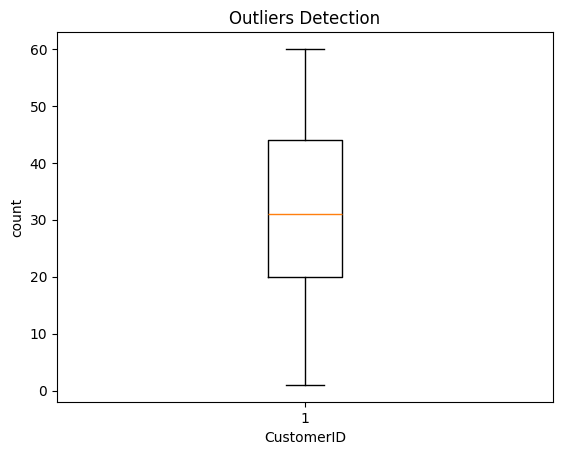

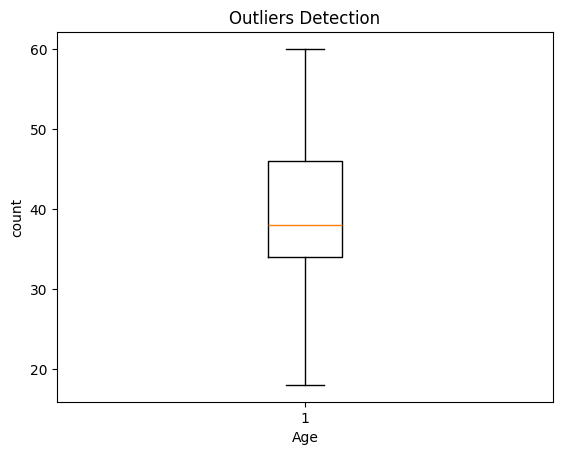

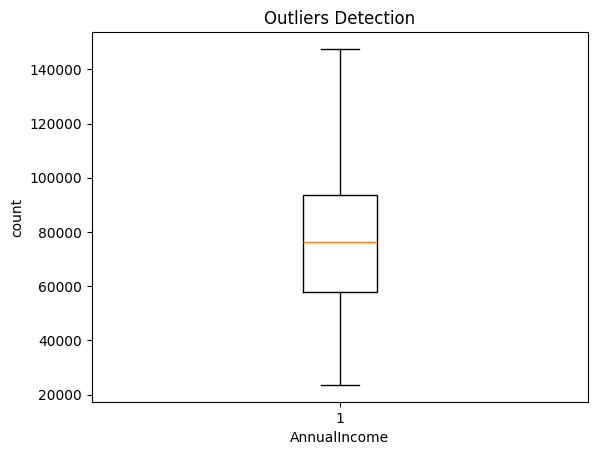

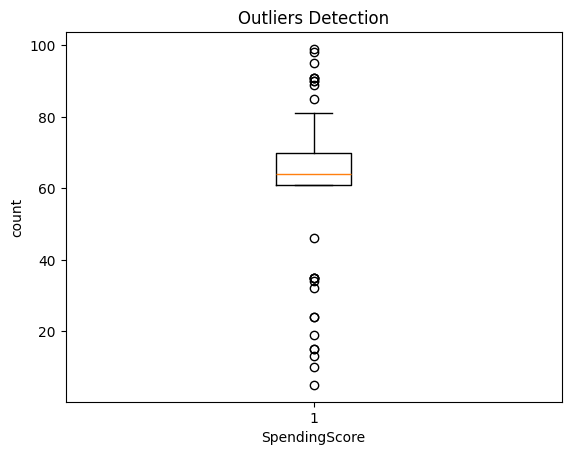

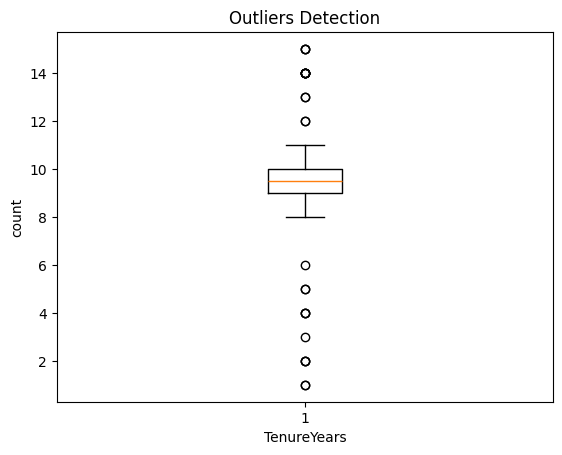

In [19]:
for x in df.columns:
    if df[x].dtypes == 'object':
        continue
    plt.boxplot(df[x])
    plt.xlabel(x)
    plt.ylabel('count')
    plt.title("Outliers Detection")
    plt.show()

In [22]:
df['TenureYears'].value_counts().sort_index()

TenureYears
1.0      2
2.0      3
3.0      1
4.0      3
5.0      2
6.0      1
8.0      3
9.0      4
9.5     27
10.0     3
11.0     2
12.0     2
13.0     2
14.0     7
15.0     3
Name: count, dtype: int64

In [24]:
df['SpendingScore'].value_counts().sort_index()

SpendingScore
5.0      1
10.0     1
13.0     1
15.0     2
19.0     1
24.0     2
32.0     1
34.0     1
35.0     4
46.0     1
61.0     4
62.0     1
64.0    25
66.0     1
68.0     2
70.0     1
71.0     1
74.0     1
75.0     1
78.0     2
81.0     1
85.0     1
89.0     1
90.0     2
91.0     3
95.0     1
98.0     1
99.0     1
Name: count, dtype: int64

In [23]:
df

,CustomerID,Name,Age,Gender,City,AnnualIncome,SpendingScore,TenureYears
0,1.0,Riya,38.0,Male,Chennai,60899.0,81.0,3.0
1,2.0,Amit,20.0,Female,Chennai,87909.0,64.0,9.0
2,3.0,Meera,24.0,Male,Bangalore,93738.0,64.0,9.5
3,4.0,Amit,27.0,Male,Chennai,128359.0,64.0,9.5
4,5.0,Riya,43.0,Female,Hyderabad,75837.0,75.0,15.0
...,...,...,...,...,...,...,...,...
60,6.0,Amit,38.0,Female,Chennai,76208.0,61.0,14.0
61,31.0,Neha,34.0,Male,Chennai,76208.0,91.0,9.5
62,21.0,Vikram,45.0,Female,Chennai,76208.0,64.0,9.5
63,6.0,Amit,38.0,Female,Chennai,76208.0,61.0,14.0


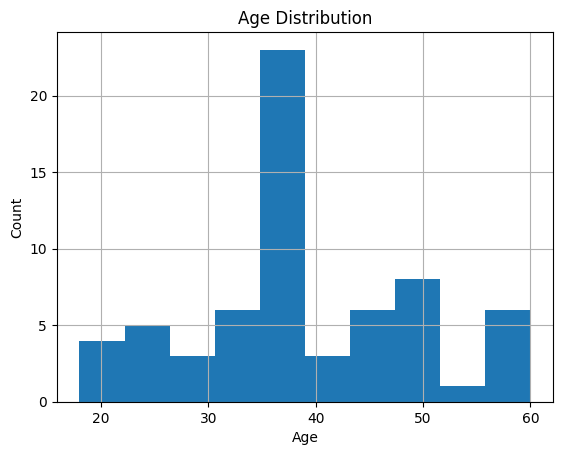

In [31]:
df['Age'].hist()
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

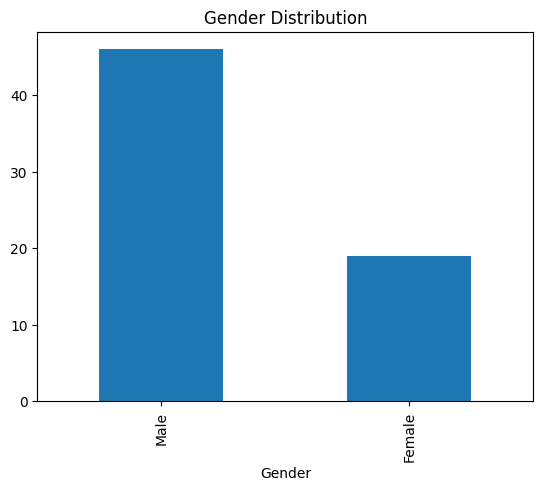

In [28]:
plt.figure()
df['Gender'].value_counts().plot(kind='bar')
plt.title("Gender Distribution")
plt.show()

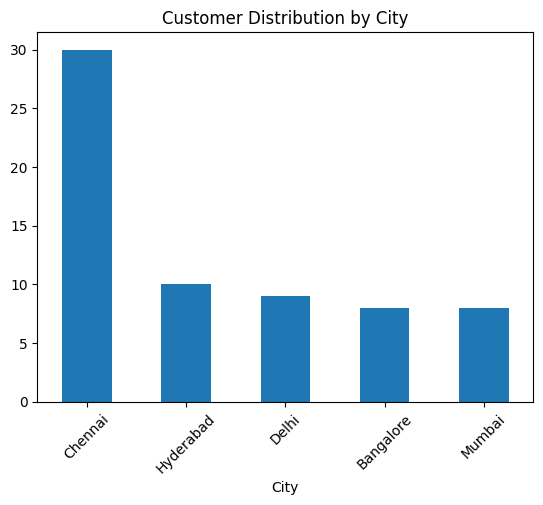

In [33]:
df['City'].value_counts().plot(kind='bar')
plt.title("Customer Distribution by City")
plt.xticks(rotation=45)
plt.show()